In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

df = pd.read_csv('TS (1).csv')
target_col = 'Users'

print(df.head())
print(f"Кол-во строк: {len(df)}")
print(f"Колонки: {list(df.columns)}")

          Time  Users
0  1/1/17 0:00  34002
1  1/1/17 1:00  37947
2  1/1/17 2:00  41517
3  1/1/17 3:00  44476
4  1/1/17 4:00  46234
Кол-во строк: 2625
Колонки: ['Time', 'Users']


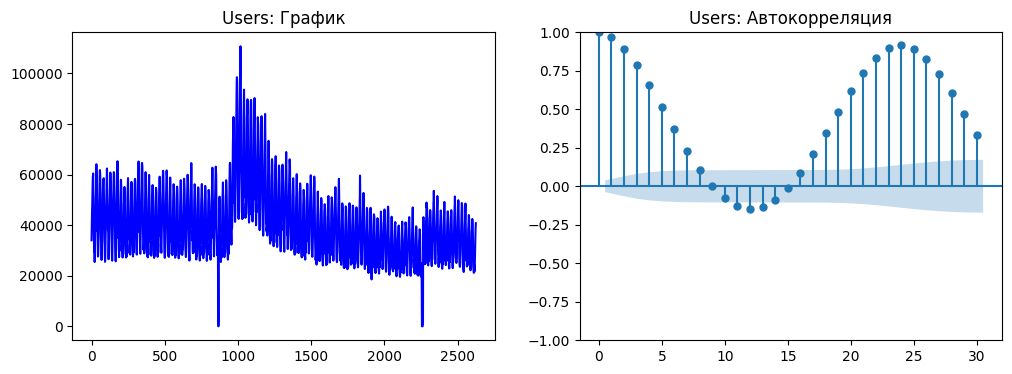

Р-value: 0.1902


In [16]:
def plot_analysis(series, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(series, color='blue')
    plt.title(f'{title}: График')

    plt.subplot(1, 2, 2)
    sm.graphics.tsa.plot_acf(series.dropna(), lags=30, ax=plt.gca())
    plt.title(f'{title}: Автокорреляция')
    plt.show()

plot_analysis(df[target_col], "Users")
res_orig = adfuller(df[target_col].dropna())
print(f"Р-value: {res_orig[1]:.4f}")

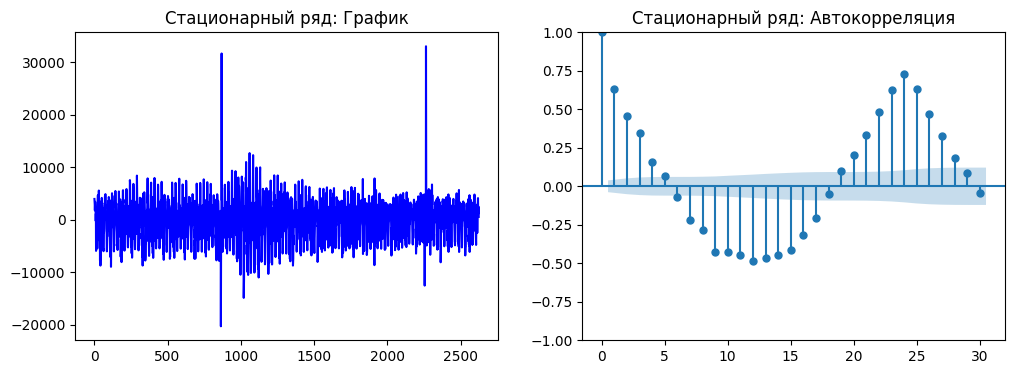

Р-value: 0.0000


In [17]:
df['Stationary'] = df[target_col].diff()
df.dropna(inplace=True)

plot_analysis(df['Stationary'], "Стационарный ряд")
res_stat = adfuller(df['Stationary'])
print(f"Р-value: {res_stat[1]:.4f}")

In [18]:
from sklearn.preprocessing import StandardScaler
window_size = 12
X, y = [], []
data = df['Stationary'].values.reshape(-1, 1)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data).flatten()

for i in range(len(data_scaled) - window_size):
    X.append(data_scaled[i:i + window_size])
    y.append(data_scaled[i + window_size])

X, y = np.array(X), np.array(y)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [14]:
model_mlp = Sequential([
    Dense(64, activation='relu', input_shape=(window_size,)),
    Dense(32, activation='relu'),
    Dense(1)
])
model_mlp.compile(optimizer='adam', loss='mse')
model_mlp.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
from xgboost import XGBRegressor
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [21]:
pred_mlp_scaled = model_mlp.predict(X_test)
pred_xgb_scaled = model_xgb.predict(X_test)

pred_mlp = scaler.inverse_transform(pred_mlp_scaled)
pred_xgb = scaler.inverse_transform(pred_xgb_scaled.reshape(-1, 1))
true_values = scaler.inverse_transform(y_test.reshape(-1, 1))


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [22]:
r2_mlp = r2_score(true_values, pred_mlp)
r2_xgb = r2_score(true_values, pred_xgb)

print(f"R2(Нейросеть) = {r2_mlp:.4f}")
print(f"R2(Деревья) = {r2_xgb:.4f}")

R2(Нейросеть) = 0.3859
R2(Деревья) = 0.4707


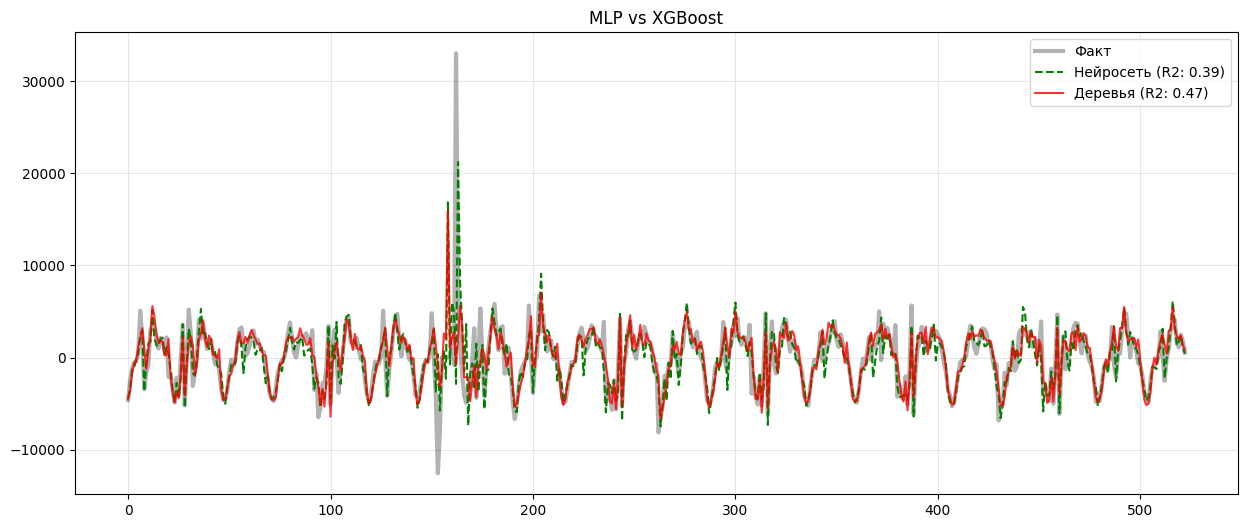

In [23]:
plt.figure(figsize=(15, 6))
plt.plot(true_values, label='Факт', color='black', alpha=0.3, linewidth=3)
plt.plot(pred_mlp, label=f'Нейросеть (R2: {r2_mlp:.2f})', color='green', linestyle='--')
plt.plot(pred_xgb, label=f'Деревья (R2: {r2_xgb:.2f})', color='red', alpha=0.8)
plt.title('MLP vs XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
#Прогноз

last_window = data_scaled[-window_size:].reshape(1, -1)
future_diffs_scaled = []

curr_window = last_window.copy()
for _ in range(5):
    p = model_xgb.predict(curr_window)
    future_diffs_scaled.append(p)
    curr_window = np.append(curr_window[:, 1:], p).reshape(1, -1)

future_diffs = scaler.inverse_transform(np.array(future_diffs_scaled).reshape(-1, 1)).flatten()

last_real_val = df[target_col].iloc[-1]
future_points = []
for d in future_diffs:
    last_real_val += d
    future_points.append(last_real_val)

print(f"По данным {df[target_col].iloc[-1]:.0f}")
for i, p in enumerate(future_points, 1):
    print(f" Шаг {i}: Ожидается {p:.0f}, изменение: {future_diffs[i-1]:+.0f})")

По данным 40763
 Шаг 1: Ожидается 42019, изменение: +1256)
 Шаг 2: Ожидается 43765, изменение: +1745)
 Шаг 3: Ожидается 43767, изменение: +2)
 Шаг 4: Ожидается 44285, изменение: +518)
 Шаг 5: Ожидается 44113, изменение: -172)
